<a href="https://colab.research.google.com/github/de-Zest/python-ai-governance/blob/main/phase2-data-handling/03_visualizing_eval_results.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Visualizing Eval Results
# Goal: Turn Eval Metrics Into Charts for Reporting
# Date: May 2026
# Status: In Progress

import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
import os

# Mount Drive and reload data
drive.mount('/content/drive')
SAVE_PATH = "/content/drive/MyDrive/python-ai-governance/data/"
df = pd.read_csv(SAVE_PATH + "ai_governance_eval_results.csv")

# Short Labels for charts - full prompts are too long
df["label"] = [
    "EU AI Act",
    "NIST Framework",
    "RLHF",
    "AI Governance"
]

print("Data loaded ✅")
print(df[["label","word_count","response_time","keyword_score"]])

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Data loaded ✅
            label  word_count  response_time  keyword_score
0       EU AI Act         563          10.25              5
1  NIST Framework         585           9.88              5
2            RLHF         666          11.00              4
3   AI Governance         657          20.68              6


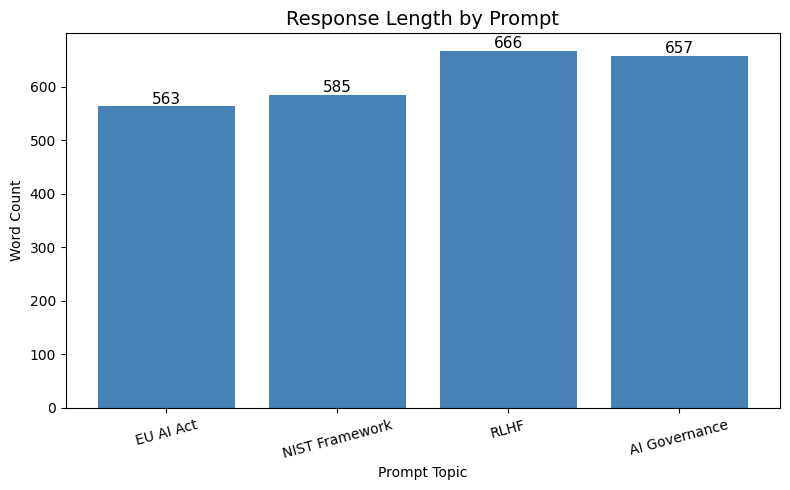

Chart saved ✅


In [ ]:
# Chart 1 - Word count per prompt
plt.figure(figsize=(8, 5))
plt.bar(df["label"], df["word_count"], color="steelblue")
plt.title("Response Length by Prompt", fontsize=14)
plt.xlabel("Prompt Topic")
plt.ylabel("Word Count")
plt.xticks(rotation=15)

# Add value labels on top of each bar
for i, val in enumerate(df["word_count"]):
    plt.text(i, val + 5, str(val), ha='center', fontsize=11)

plt.tight_layout()
plt.savefig(SAVE_PATH + "chart_word_count.png")
plt.show()
print("Chart saved ✅")

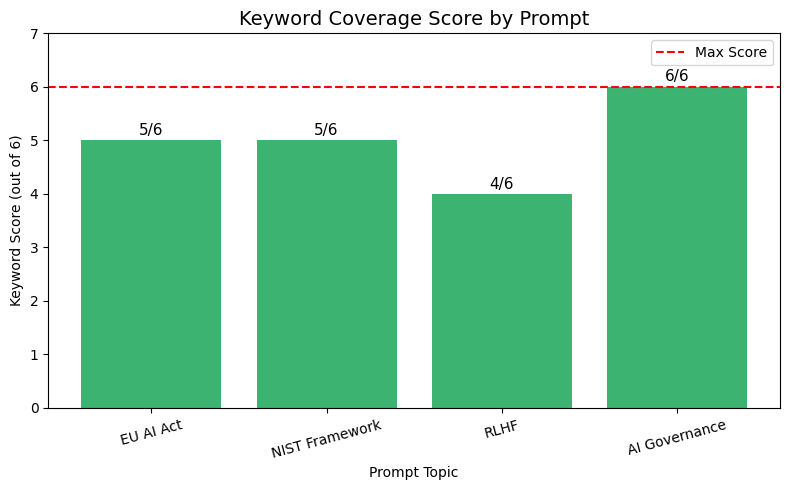

Chart saved ✅


In [ ]:
# Chart 3 - Keyword Score per prompt
plt.figure(figsize=(8, 5))
bars = plt.bar(df["label"], df["keyword_score"], color="mediumseagreen")
plt.title("Keyword Coverage Score by Prompt", fontsize=14)
plt.xlabel("Prompt Topic")
plt.ylabel("Keyword Score (out of 6)")
plt.ylim(0, 7)
plt.xticks(rotation=15)
plt.axhline(y=6, color='red', linestyle="--", label="Max Score")
plt.legend()

# Add value labels on top of each bar
for i, val in enumerate(df["keyword_score"]):
    plt.text(i, val + 0.1, f"{val}/6", ha="center", fontsize=11)

plt.tight_layout()
plt.savefig(SAVE_PATH + "chart_keyword_score.png")
plt.show()
print("Chart saved ✅")



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


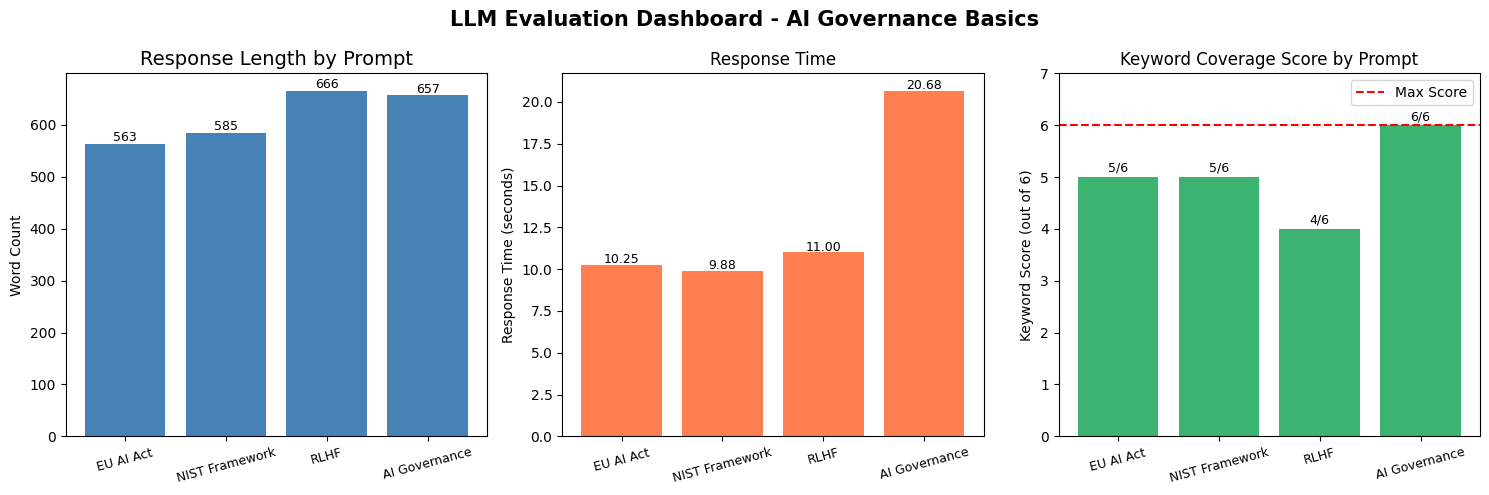

Dashboard saved ✅


In [ ]:
# Chart 4 - Combined Dashboard
import matplotlib.pyplot as plt
import pandas as pd
from google.colab import drive
import os

drive.mount('/content/drive')
SAVE_PATH = "/content/drive/MyDrive/python-ai-governance/data/"
df = pd.read_csv(SAVE_PATH + "ai_governance_eval_results.csv")

# Short Labels for charts - full prompts are too long
df["label"] = [
    "EU AI Act",
    "NIST Framework",
    "RLHF",
    "AI Governance"
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("LLM Evaluation Dashboard - AI Governance Basics", fontsize=15, fontweight="bold")

# Plot 1 - Word Count
axes[0].bar(df["label"], df["word_count"], color="steelblue")
axes[0].set_title("Response Length by Prompt", fontsize=14)
axes[0].set_xticks(range(len(df["label"]))) # Set ticks explicitly
axes[0].set_xticklabels(df["label"], rotation=15, fontsize=9)
axes[0].set_ylabel("Word Count")
for i, val in enumerate(df["word_count"]):
    axes[0].text(i, val + 5, str(val), ha='center', fontsize=9)

# Plot 2 - Response Time
axes[1].bar(df["label"], df["response_time"], color="coral")
axes[1].set_title("Response Time")
axes[1].set_xticks(range(len(df["label"]))) # Set ticks explicitly
axes[1].set_xticklabels(df["label"], rotation=15, fontsize=9)
axes[1].set_ylabel("Response Time (seconds)")
for i, val in enumerate(df["response_time"]):
    axes[1].text(i, val + 0.1, f"{val:.2f}", ha='center', fontsize=9)

# Plot 3 - Keyword Score
axes[2].bar(df["label"], df["keyword_score"], color="mediumseagreen")
axes[2].set_title("Keyword Coverage Score by Prompt")
axes[2].set_xticks(range(len(df["label"]))) # Set ticks explicitly
axes[2].set_xticklabels(df["label"], rotation=15, fontsize=9)
axes[2].set_ylabel("Keyword Score (out of 6)")
axes[2].set_ylim(0, 7)
axes[2].axhline(y=6, color='red', linestyle="--", label="Max Score")
axes[2].legend()
for i, val in enumerate(df["keyword_score"]):
    axes[2].text(i, val + 0.1, f"{val}/6", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig(SAVE_PATH + "chart_eval_dashboard.png")
plt.show()
print("Dashboard saved ✅")

## Findings — AI Governance Basics Evaluation

**Model tested:** gemini-flash-latest  
**Date:** May 2026  
**Prompts evaluated:** 4

### Key Findings

1. **Response Length:** RLHF generated the longest response (666 words).
   Broader technical topics produce more verbose outputs.

2. **Response Time:** AI Governance was slowest at 20.68s despite not being
   the longest response — suggesting deeper reasoning on broad topics.

3. **Keyword Coverage:** AI Governance scored perfect 6/6. RLHF scored
   lowest at 4/6 — the model uses technical vocabulary rather than
   governance keywords for that topic.

4. **Key Limitation:** Keyword scoring penalizes responses that use
   synonyms or related concepts instead of exact keywords.
   A semantic scoring approach would be more accurate.

### Recommendation
Expand keyword list for RLHF prompts to include technical terms
like "feedback", "reward", "alignment", "fine-tuning".